# Выбор финальных гиперпараметров 4 Fine-tuning протоколов

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
pd.set_option("display.max_rows", 200)

In [5]:
PROJECT_ROOT = Path(r"C:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\Fine-tuning_ОСНОВНОЙ_ЭКСПЕРИМЕНТ\Dev-tuning")
RESULTS_DIR = PROJECT_ROOT / "block4_phase2_results"
SUMMARY_PATH = PROJECT_ROOT / "summary_results.csv"

In [6]:
df = pd.read_csv(SUMMARY_PATH)
print(df.shape)
df.head()

(192, 28)


,subject_id,group,p,scenario,ft_strategy,seed,encoder_checkpoint,lr_encoder,lr_head,weight_decay,warmup_epochs,selected_threshold,val_f1_at_selected_threshold,n_calib,n_val,n_test,n_pos_calib,n_pos_val,n_pos_test,best_epoch,best_val_loss,stopped_epoch,auc,accuracy,f1,precision,recall,fdr
0,subj_054,benchmark,10,ssl_ft,partial_ft,42,/kaggle/input/datasets/taisiyaglazova/ssl-full...,0.00001,0.0001,0.0001,NaN,0.05,0.210526,677,136,2899,80,16,341,6,0.687197,16,0.499371,0.117627,0.210494,0.117627,1.000000,0.003596
1,subj_054,benchmark,10,ssl_ft,partial_ft,42,/kaggle/input/datasets/taisiyaglazova/ssl-full...,0.00001,0.0001,0.0010,NaN,0.05,0.210526,677,136,2899,80,16,341,6,0.687197,16,0.499369,0.117627,0.210494,0.117627,1.000000,0.003596
2,subj_054,benchmark,10,ssl_ft,partial_ft,42,/kaggle/input/datasets/taisiyaglazova/ssl-full...,0.00001,0.0003,0.0001,NaN,0.40,0.211921,677,136,2899,80,16,341,6,0.688845,16,0.510646,0.133494,0.212045,0.118721,0.991202,0.005115
3,subj_054,benchmark,10,ssl_ft,partial_ft,42,/kaggle/input/datasets/taisiyaglazova/ssl-full...,0.00001,0.0003,0.0010,NaN,0.40,0.211921,677,136,2899,80,16,341,6,0.688845,16,0.510647,0.133494,0.212045,0.118721,0.991202,0.005115
4,subj_054,benchmark,10,ssl_ft,partial_ft,42,/kaggle/input/datasets/taisiyaglazova/ssl-full...,0.00003,0.0001,0.0001,NaN,0.05,0.210526,677,136,2899,80,16,341,6,0.687593,16,0.502236,0.117627,0.210494,0.117627,1.000000,0.004555


In [10]:
df['subject_id'].unique()

array(['subj_054', 'subj_065', 'subj_090', 'subj_094'], dtype=object)

In [7]:
df.columns.tolist()

['subject_id',
 'group',
 'p',
 'scenario',
 'ft_strategy',
 'seed',
 'encoder_checkpoint',
 'lr_encoder',
 'lr_head',
 'weight_decay',
 'warmup_epochs',
 'selected_threshold',
 'val_f1_at_selected_threshold',
 'n_calib',
 'n_val',
 'n_test',
 'n_pos_calib',
 'n_pos_val',
 'n_pos_test',
 'best_epoch',
 'best_val_loss',
 'stopped_epoch',
 'auc',
 'accuracy',
 'f1',
 'precision',
 'recall',
 'fdr']

In [8]:
agg = (
    df.groupby(["ft_strategy", "lr_encoder", "lr_head", "weight_decay", "p"], as_index=False)
    .agg(
        mean_auc=("auc", "mean"),
        std_auc=("auc", "std"),
        mean_f1=("f1", "mean"),
        std_f1=("f1", "std"),
    )
)

agg = agg.sort_values(["p", "mean_auc"], ascending=[True, False])
agg.head(30)

,ft_strategy,lr_encoder,lr_head,weight_decay,p,mean_auc,std_auc,mean_f1,std_f1
18,partial_ft,0.00003,0.0003,0.0001,10,0.514461,0.011220,0.182656,0.033468
21,partial_ft,0.00003,0.0003,0.0010,10,0.514459,0.011221,0.182656,0.033468
15,partial_ft,0.00003,0.0001,0.0010,10,0.513002,0.025604,0.185444,0.036145
12,partial_ft,0.00003,0.0001,0.0001,10,0.513002,0.025602,0.185444,0.036145
42,warmup,0.00003,0.0003,0.0001,10,0.512096,0.018008,0.184703,0.033855
45,warmup,0.00003,0.0003,0.0010,10,0.512039,0.018016,0.183622,0.033461
9,partial_ft,0.00001,0.0003,0.0010,10,0.511660,0.004617,0.183154,0.033007
6,partial_ft,0.00001,0.0003,0.0001,10,0.511659,0.004618,0.183154,0.033007
3,partial_ft,0.00001,0.0001,0.0010,10,0.507776,0.021931,0.182404,0.034094
0,partial_ft,0.00001,0.0001,0.0001,10,0.507775,0.021933,0.182423,0.034118


In [11]:
agg_overall = (
    df.groupby(["ft_strategy", "lr_encoder", "lr_head", "weight_decay"], as_index=False)
    .agg(
        mean_auc=("auc", "mean"),
        std_auc=("auc", "std"),
        mean_f1=("f1", "mean"),
        std_f1=("f1", "std"),
    )
    .sort_values("mean_auc", ascending=False)
)

agg_overall.head(20)

,ft_strategy,lr_encoder,lr_head,weight_decay,mean_auc,std_auc,mean_f1,std_f1
7,partial_ft,0.00003,0.0003,0.0010,0.539117,0.037688,0.187575,0.030884
6,partial_ft,0.00003,0.0003,0.0001,0.539116,0.037682,0.187565,0.030870
14,warmup,0.00003,0.0003,0.0001,0.536531,0.026420,0.182671,0.030304
15,warmup,0.00003,0.0003,0.0010,0.536307,0.026465,0.182686,0.030300
4,partial_ft,0.00003,0.0001,0.0001,0.534835,0.044434,0.188718,0.031784
5,partial_ft,0.00003,0.0001,0.0010,0.534835,0.044430,0.188718,0.031784
11,warmup,0.00001,0.0003,0.0010,0.534396,0.027497,0.182943,0.029571
10,warmup,0.00001,0.0003,0.0001,0.534374,0.027487,0.183044,0.029496
3,partial_ft,0.00001,0.0003,0.0010,0.532023,0.034744,0.185467,0.028351
2,partial_ft,0.00001,0.0003,0.0001,0.532023,0.034745,0.185467,0.028351


## Визуализация

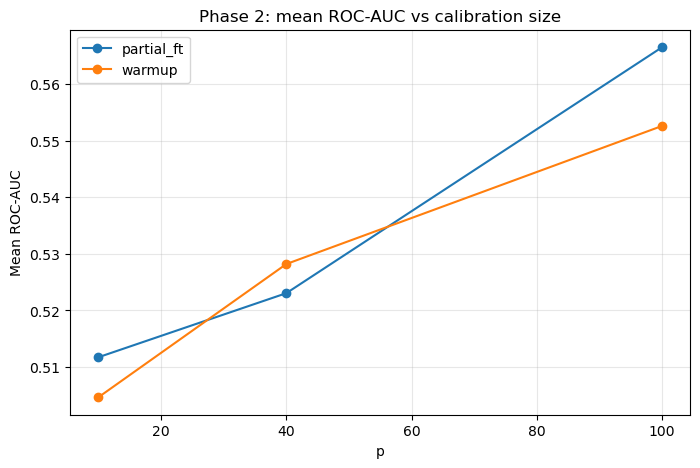

In [12]:
plot_df = (
    df.groupby(["ft_strategy", "p"], as_index=False)
    .agg(mean_auc=("auc", "mean"))
)

plt.figure(figsize=(8, 5))

for strategy in sorted(plot_df["ft_strategy"].unique()):
    sub = plot_df[plot_df["ft_strategy"] == strategy].sort_values("p")
    plt.plot(sub["p"], sub["mean_auc"], marker="o", label=strategy)

plt.xlabel("p")
plt.ylabel("Mean ROC-AUC")
plt.title("Phase 2: mean ROC-AUC vs calibration size")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [13]:
for strategy in ["partial_ft", "warmup"]:
    print("=" * 80)
    print(strategy)

    display(
        agg_overall[agg_overall["ft_strategy"] == strategy]
        .sort_values("mean_auc", ascending=False)
        .reset_index(drop=True)
    )

partial_ft


,ft_strategy,lr_encoder,lr_head,weight_decay,mean_auc,std_auc,mean_f1,std_f1
0,partial_ft,0.00003,0.0003,0.0010,0.539117,0.037688,0.187575,0.030884
1,partial_ft,0.00003,0.0003,0.0001,0.539116,0.037682,0.187565,0.030870
2,partial_ft,0.00003,0.0001,0.0001,0.534835,0.044434,0.188718,0.031784
3,partial_ft,0.00003,0.0001,0.0010,0.534835,0.044430,0.188718,0.031784
4,partial_ft,0.00001,0.0003,0.0010,0.532023,0.034744,0.185467,0.028351
5,partial_ft,0.00001,0.0003,0.0001,0.532023,0.034745,0.185467,0.028351
6,partial_ft,0.00001,0.0001,0.0001,0.529066,0.037866,0.185430,0.028890
7,partial_ft,0.00001,0.0001,0.0010,0.529064,0.037865,0.185424,0.028883


warmup


,ft_strategy,lr_encoder,lr_head,weight_decay,mean_auc,std_auc,mean_f1,std_f1
0,warmup,0.00003,0.0003,0.0001,0.536531,0.026420,0.182671,0.030304
1,warmup,0.00003,0.0003,0.0010,0.536307,0.026465,0.182686,0.030300
2,warmup,0.00001,0.0003,0.0010,0.534396,0.027497,0.182943,0.029571
3,warmup,0.00001,0.0003,0.0001,0.534374,0.027487,0.183044,0.029496
4,warmup,0.00003,0.0001,0.0010,0.522605,0.019843,0.182071,0.029206
5,warmup,0.00003,0.0001,0.0001,0.522568,0.019859,0.182106,0.029235
6,warmup,0.00001,0.0001,0.0010,0.520784,0.024432,0.182388,0.029804
7,warmup,0.00001,0.0001,0.0001,0.520293,0.025174,0.182388,0.029793


In [14]:
df_hp = agg_overall.copy()
df_hp["config"] = (
    "enc=" + df_hp["lr_encoder"].astype(str) +
    ", head=" + df_hp["lr_head"].astype(str) +
    ", wd=" + df_hp["weight_decay"].astype(str)
)

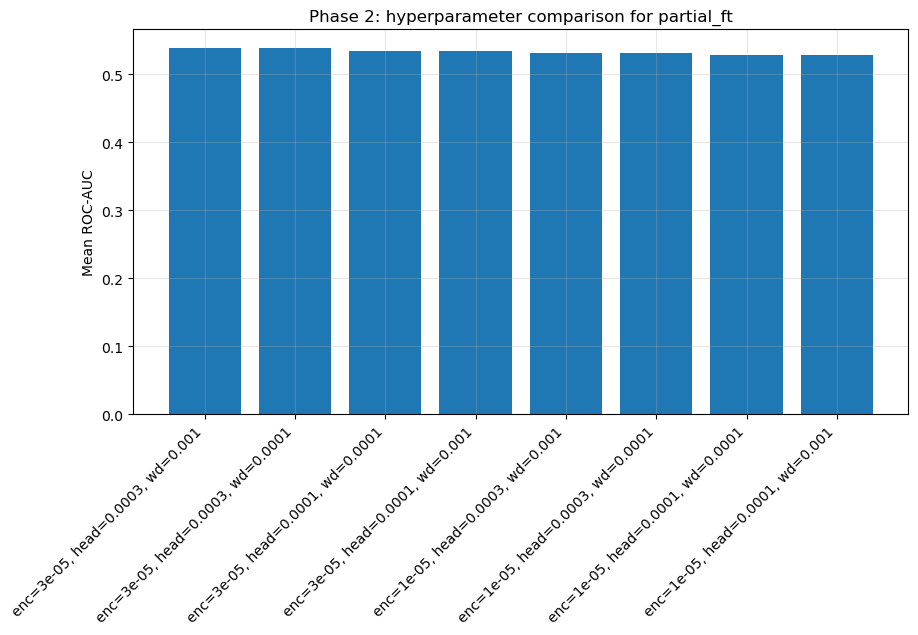

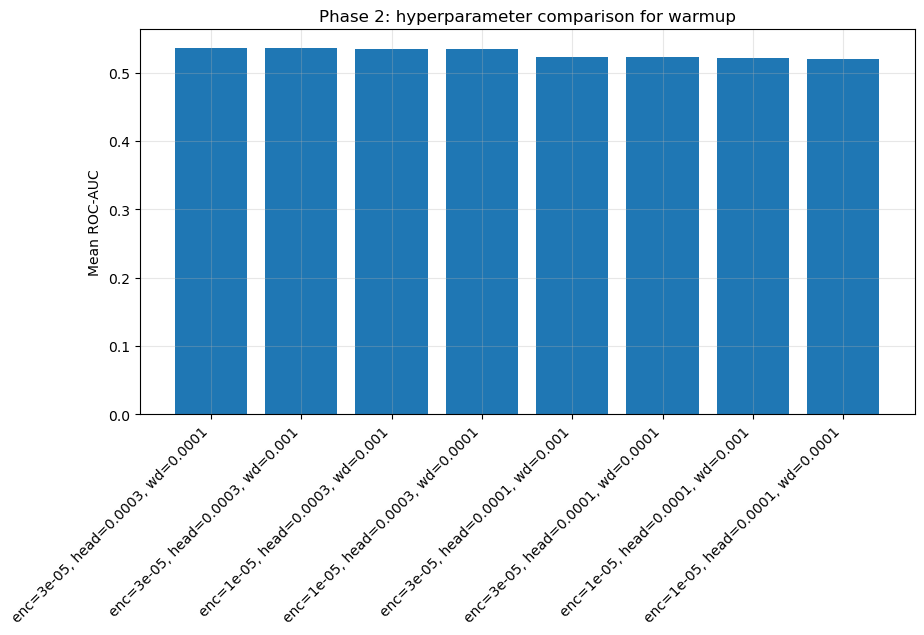

In [15]:
for strategy in ["partial_ft", "warmup"]:
    sub = (
        df_hp[df_hp["ft_strategy"] == strategy]
        .sort_values("mean_auc", ascending=False)
        .reset_index(drop=True)
    )

    plt.figure(figsize=(10, 5))
    plt.bar(sub["config"], sub["mean_auc"])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Mean ROC-AUC")
    plt.title(f"Phase 2: hyperparameter comparison for {strategy}")
    plt.grid(True, alpha=0.3)
    plt.show()

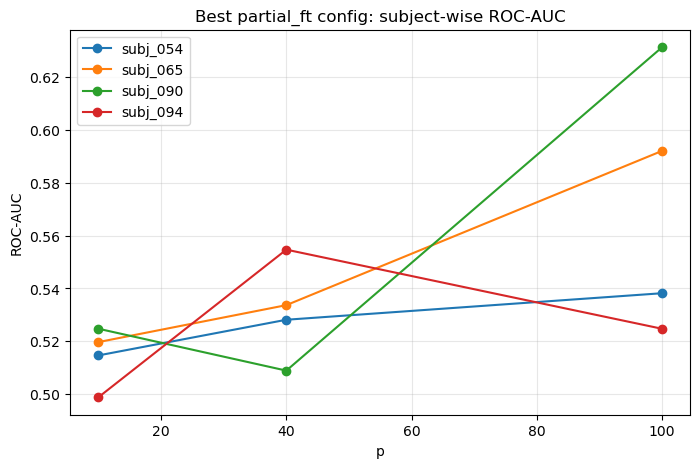

In [16]:
best_partial = (
    agg_overall[agg_overall["ft_strategy"] == "partial_ft"]
    .sort_values("mean_auc", ascending=False)
    .iloc[0]
)

mask = (
    (df["ft_strategy"] == "partial_ft") &
    (df["lr_encoder"] == best_partial["lr_encoder"]) &
    (df["lr_head"] == best_partial["lr_head"]) &
    (df["weight_decay"] == best_partial["weight_decay"])
)

subj_df = df[mask].copy()

plt.figure(figsize=(8, 5))

for subject in sorted(subj_df["subject_id"].unique()):
    sub = subj_df[subj_df["subject_id"] == subject].sort_values("p")
    plt.plot(sub["p"], sub["auc"], marker="o", label=subject)

plt.xlabel("p")
plt.ylabel("ROC-AUC")
plt.title("Best partial_ft config: subject-wise ROC-AUC")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [17]:
final_rank = (
    agg_overall.sort_values("mean_auc", ascending=False)
    .reset_index(drop=True)
)

final_rank.head(10)

,ft_strategy,lr_encoder,lr_head,weight_decay,mean_auc,std_auc,mean_f1,std_f1
0,partial_ft,0.00003,0.0003,0.0010,0.539117,0.037688,0.187575,0.030884
1,partial_ft,0.00003,0.0003,0.0001,0.539116,0.037682,0.187565,0.030870
2,warmup,0.00003,0.0003,0.0001,0.536531,0.026420,0.182671,0.030304
3,warmup,0.00003,0.0003,0.0010,0.536307,0.026465,0.182686,0.030300
4,partial_ft,0.00003,0.0001,0.0001,0.534835,0.044434,0.188718,0.031784
5,partial_ft,0.00003,0.0001,0.0010,0.534835,0.044430,0.188718,0.031784
6,warmup,0.00001,0.0003,0.0010,0.534396,0.027497,0.182943,0.029571
7,warmup,0.00001,0.0003,0.0001,0.534374,0.027487,0.183044,0.029496
8,partial_ft,0.00001,0.0003,0.0010,0.532023,0.034744,0.185467,0.028351
9,partial_ft,0.00001,0.0003,0.0001,0.532023,0.034745,0.185467,0.028351


In [18]:
rank_p100 = (
    agg[agg["p"] == 100]
    .sort_values("mean_auc", ascending=False)
    .reset_index(drop=True)
)

rank_p100.head(10)

,ft_strategy,lr_encoder,lr_head,weight_decay,p,mean_auc,std_auc,mean_f1,std_f1
0,partial_ft,0.00003,0.0001,0.0001,100,0.572795,0.058953,0.200879,0.033664
1,partial_ft,0.00003,0.0001,0.0010,100,0.572788,0.058948,0.200879,0.033664
2,partial_ft,0.00003,0.0003,0.0010,100,0.571558,0.049322,0.199705,0.033400
3,partial_ft,0.00003,0.0003,0.0001,100,0.571550,0.049314,0.199678,0.033363
4,partial_ft,0.00001,0.0001,0.0001,100,0.563438,0.045797,0.192164,0.027563
5,partial_ft,0.00001,0.0001,0.0010,100,0.563433,0.045798,0.192164,0.027563
6,warmup,0.00003,0.0003,0.0010,100,0.562075,0.019380,0.182730,0.033578
7,warmup,0.00003,0.0003,0.0001,100,0.562066,0.019429,0.182261,0.033817
8,warmup,0.00001,0.0003,0.0010,100,0.561544,0.024026,0.184350,0.031539
9,warmup,0.00001,0.0003,0.0001,100,0.561496,0.023948,0.184619,0.031260


## Финальное решение

In [ ]:
lr_encoder = 3e-5
lr_head = 3e-4
weight_decay = 1e-3
warmup_epochs = 3